# 11. Analysis: COMET Pipeline

This notebook is the main analysis notebook for the project. It uses the validated COMET outputs and merged automatic metrics as the current source of truth, and it is designed to incorporate human evaluation results later once annotation is complete.

## Scope
- Compare baseline, idiom-only, LoRA, and FLAN models
- Analyze performance on both `idioms_test` and `wmt_test`
- Use COMET as the primary semantic metric
- Use BLEU and chrF as supporting automatic metrics
- Reserve a dedicated section for human evaluation once available


# 0. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path('/content/drive/MyDrive/ds266_idiom_mt')
RESULTS_DIR = PROJECT_DIR / 'results'
COMET_EVAL_DIR = PROJECT_DIR / 'qual_preds' / 'comet_eval'

FILES = {
    'automatic_plus_comet': RESULTS_DIR / 'automatic_plus_comet.csv',
    'comet_sentence_scores': COMET_EVAL_DIR / 'comet_sentence_scores.csv',
    'comet_sentence_spread': COMET_EVAL_DIR / 'comet_sentence_spread.csv',
    'comet_summary_by_group': COMET_EVAL_DIR / 'comet_summary_by_group.csv',
    'comet_summary_overall': COMET_EVAL_DIR / 'comet_summary_overall.csv',
}

for name, path in FILES.items():
    print(f'{name}: {path} | exists={path.exists()}')


automatic_plus_comet: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_plus_comet.csv | exists=True
comet_sentence_scores: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_sentence_scores.csv | exists=True
comet_sentence_spread: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_sentence_spread.csv | exists=True
comet_summary_by_group: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_summary_by_group.csv | exists=True
comet_summary_overall: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_summary_overall.csv | exists=True


## 2. Load Data Sources

In [3]:
scores = pd.read_csv(FILES['comet_sentence_scores'])
spread = pd.read_csv(FILES['comet_sentence_spread'])
summary_by_group = pd.read_csv(FILES['comet_summary_by_group'])
summary_overall = pd.read_csv(FILES['comet_summary_overall'])
merged_metrics = pd.read_csv(FILES['automatic_plus_comet'])

print('Loaded successfully.')
print('scores:', scores.shape)
print('spread:', spread.shape)
print('summary_by_group:', summary_by_group.shape)
print('summary_overall:', summary_overall.shape)
print('merged_metrics:', merged_metrics.shape)


Loaded successfully.
scores: (500, 11)
spread: (50, 16)
summary_by_group: (20, 6)
summary_overall: (10, 5)
merged_metrics: (20, 8)


## 3. Input data validation

These checks help confirm that the notebook is using the expected source-of-truth files.

In [4]:
print('Duplicate (src, model, group) rows:', scores.duplicated(['src', 'model', 'group']).sum())
print('\nRows per (group, model):')
display(scores.groupby(['group', 'model']).size().rename('n_rows').reset_index())

print('\nModels present in sentence-level scores:')
display(pd.Series(sorted(scores['model'].unique()), name='model'))

Duplicate (src, model, group) rows: 0

Rows per (group, model):


,group,model,n_rows
0,idioms_test,baseline,25
1,idioms_test,flan_t5_small_prompt_0shot,25
2,idioms_test,flan_t5_small_prompt_3shot,25
3,idioms_test,flan_t5_small_prompt_5shot,25
4,idioms_test,idiom_only_v1,25
5,idioms_test,lora_r16_stage2,25
6,idioms_test,lora_r4_stage2,25
7,idioms_test,lora_r8_stage2,25
8,idioms_test,mixed_data_v1,25
9,idioms_test,two_stage_frozen_v1,25



Models present in sentence-level scores:


,model
0,baseline
1,flan_t5_small_prompt_0shot
2,flan_t5_small_prompt_3shot
3,flan_t5_small_prompt_5shot
4,idiom_only_v1
5,lora_r16_stage2
6,lora_r4_stage2
7,lora_r8_stage2
8,mixed_data_v1
9,two_stage_frozen_v1


## 4. Compared models

In [5]:
model_notes = pd.DataFrame({
    'model_label': [
        'baseline',
        'idiom_only_v1',
        'two_stage_frozen_v1',
        'mixed_data_v1',
        'lora_r4_stage2',
        'lora_r8_stage2',
        'lora_r16_stage2',
        'flan_t5_small_prompt_0shot',
        'flan_t5_small_prompt_3shot',
        'flan_t5_small_prompt_5shot',
    ],
    'family': [
        'Helsinki baseline',
        'Full fine-tune',
        'Two-stage full fine-tune',
        'Mixed-data full fine-tune',
        'LoRA',
        'LoRA',
        'LoRA',
        'FLAN prompting',
        'FLAN prompting',
        'FLAN prompting',
    ],
    'notes': [
        'Pretrained EN→DE baseline',
        'Stage 1 idiom-only fine-tune',
        'Stage 2 WMT refinement with encoder frozen',
        'Stage 2 mixed-data refinement from idiom-only model',
        'Two-stage LoRA rank 4',
        'Two-stage LoRA rank 8',
        'Two-stage LoRA rank 16',
        'FLAN 0-shot',
        'FLAN 3-shot',
        'FLAN 5-shot',
    ],
    'included_in_human_eval': [True, True, False, False, True, True, True, True, False, False],
})

analysis_df = merged_metrics.merge(model_notes, on='model_label', how='left')
display(model_notes)
display(analysis_df.sort_values(['split', 'comet_mean'], ascending=[True, False]).head(15))


,model_label,family,notes,included_in_human_eval
0,baseline,Helsinki baseline,Pretrained EN→DE baseline,True
1,idiom_only_v1,Full fine-tune,Stage 1 idiom-only fine-tune,True
2,two_stage_frozen_v1,Two-stage full fine-tune,Stage 2 WMT refinement with encoder frozen,False
3,mixed_data_v1,Mixed-data full fine-tune,Stage 2 mixed-data refinement from idiom-only ...,False
4,lora_r4_stage2,LoRA,Two-stage LoRA rank 4,True
5,lora_r8_stage2,LoRA,Two-stage LoRA rank 8,True
6,lora_r16_stage2,LoRA,Two-stage LoRA rank 16,True
7,flan_t5_small_prompt_0shot,FLAN prompting,FLAN 0-shot,True
8,flan_t5_small_prompt_3shot,FLAN prompting,FLAN 3-shot,False
9,flan_t5_small_prompt_5shot,FLAN prompting,FLAN 5-shot,False


,model_label,split,comet_mean,comet_std,n,bleu,chrf,metrics_source_file,family,notes,included_in_human_eval
4,idiom_only_v1,idioms_test,0.762717,0.133694,25,44.161210,64.438061,automatic_metrics_canonical.csv,Full fine-tune,Stage 1 idiom-only fine-tune,True
9,two_stage_frozen_v1,idioms_test,0.760963,0.135645,25,43.159787,63.341618,automatic_metrics_canonical.csv,Two-stage full fine-tune,Stage 2 WMT refinement with encoder frozen,False
8,mixed_data_v1,idioms_test,0.741165,0.146571,25,43.490413,62.924234,metrics.csv,Mixed-data full fine-tune,Stage 2 mixed-data refinement from idiom-only ...,False
5,lora_r16_stage2,idioms_test,0.732651,0.143304,25,41.724245,61.449820,automatic_metrics_canonical.csv,LoRA,Two-stage LoRA rank 16,True
0,baseline,idioms_test,0.732551,0.135192,25,39.649352,60.786112,automatic_metrics_canonical.csv,Helsinki baseline,Pretrained EN→DE baseline,True
7,lora_r8_stage2,idioms_test,0.732034,0.147128,25,42.178766,61.760909,automatic_metrics_canonical.csv,LoRA,Two-stage LoRA rank 8,True
6,lora_r4_stage2,idioms_test,0.728579,0.152061,25,41.853197,61.836284,automatic_metrics_canonical.csv,LoRA,Two-stage LoRA rank 4,True
1,flan_t5_small_prompt_0shot,idioms_test,0.381018,0.118532,25,8.126810,33.138795,automatic_metrics_canonical.csv,FLAN prompting,FLAN 0-shot,True
3,flan_t5_small_prompt_5shot,idioms_test,0.371568,0.127203,25,7.623039,32.096459,automatic_metrics_canonical.csv,FLAN prompting,FLAN 5-shot,False
2,flan_t5_small_prompt_3shot,idioms_test,0.363405,0.106758,25,7.769178,32.517583,automatic_metrics_canonical.csv,FLAN prompting,FLAN 3-shot,False


## 5. Quantitative results overview

In [6]:
display(summary_by_group.sort_values(['group', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))


,model,group,n,comet_mean,comet_std,input_sources
0,idiom_only_v1,idioms_test,25,0.762717,0.133694,wide_csv
1,two_stage_frozen_v1,idioms_test,25,0.760963,0.135645,wide_csv
2,mixed_data_v1,idioms_test,25,0.741165,0.146571,mixed_data
3,lora_r16_stage2,idioms_test,25,0.732651,0.143304,wide_csv
4,baseline,idioms_test,25,0.732551,0.135192,wide_csv
5,lora_r8_stage2,idioms_test,25,0.732034,0.147128,wide_csv
6,lora_r4_stage2,idioms_test,25,0.728579,0.152061,wide_csv
7,flan_t5_small_prompt_0shot,idioms_test,25,0.381018,0.118532,per_model_csvs
8,flan_t5_small_prompt_5shot,idioms_test,25,0.371568,0.127203,per_model_csvs
9,flan_t5_small_prompt_3shot,idioms_test,25,0.363405,0.106758,per_model_csvs


In [7]:
display(summary_overall.sort_values('comet_mean', ascending=False).reset_index(drop=True))


,model,n,comet_mean,comet_std,input_sources
0,idiom_only_v1,50,0.812894,0.117357,wide_csv
1,two_stage_frozen_v1,50,0.803841,0.122186,wide_csv
2,mixed_data_v1,50,0.796334,0.131866,mixed_data
3,lora_r16_stage2,50,0.789763,0.133208,wide_csv
4,lora_r8_stage2,50,0.787165,0.137748,wide_csv
5,baseline,50,0.782859,0.133687,wide_csv
6,lora_r4_stage2,50,0.780935,0.143225,wide_csv
7,flan_t5_small_prompt_0shot,50,0.427297,0.135950,per_model_csvs
8,flan_t5_small_prompt_3shot,50,0.426677,0.145595,per_model_csvs
9,flan_t5_small_prompt_5shot,50,0.402114,0.137224,per_model_csvs


### Supporting automatic metrics (COMET + BLEU + chrF)

In [8]:
display(merged_metrics.sort_values(['split', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))


,model_label,split,comet_mean,comet_std,n,bleu,chrf,metrics_source_file
0,idiom_only_v1,idioms_test,0.762717,0.133694,25,44.161210,64.438061,automatic_metrics_canonical.csv
1,two_stage_frozen_v1,idioms_test,0.760963,0.135645,25,43.159787,63.341618,automatic_metrics_canonical.csv
2,mixed_data_v1,idioms_test,0.741165,0.146571,25,43.490413,62.924234,metrics.csv
3,lora_r16_stage2,idioms_test,0.732651,0.143304,25,41.724245,61.449820,automatic_metrics_canonical.csv
4,baseline,idioms_test,0.732551,0.135192,25,39.649352,60.786112,automatic_metrics_canonical.csv
5,lora_r8_stage2,idioms_test,0.732034,0.147128,25,42.178766,61.760909,automatic_metrics_canonical.csv
6,lora_r4_stage2,idioms_test,0.728579,0.152061,25,41.853197,61.836284,automatic_metrics_canonical.csv
7,flan_t5_small_prompt_0shot,idioms_test,0.381018,0.118532,25,8.126810,33.138795,automatic_metrics_canonical.csv
8,flan_t5_small_prompt_5shot,idioms_test,0.371568,0.127203,25,7.623039,32.096459,automatic_metrics_canonical.csv
9,flan_t5_small_prompt_3shot,idioms_test,0.363405,0.106758,25,7.769178,32.517583,automatic_metrics_canonical.csv


## Baseline-relative delta table

This section compares each model to the `baseline` within each split. Positive values indicate improvement over the baseline and negative values indicate degradation.

## Baseline-relative deltas

**What this section does:**  
This section converts raw scores into differences relative to the baseline for each split. That makes it much easier to see whether a model actually improves over the baseline or merely looks strong in absolute terms.

**What to look for:**  
Positive deltas indicate improvement over the baseline. Negative deltas indicate degradation. The most important values are the COMET deltas, because COMET is the strongest semantic-quality signal in this project.

**What it means for the paper:**  
This section supports claims such as whether idiom-only fine-tuning improves idioms, whether it hurts WMT, and where mixed-data, two-stage, and LoRA land relative to the baseline.


In [9]:
baseline_rows = (
    merged_metrics[merged_metrics['model_label'] == 'baseline'][['split', 'bleu', 'chrf', 'comet_mean']]
    .rename(columns={
        'bleu': 'baseline_bleu',
        'chrf': 'baseline_chrf',
        'comet_mean': 'baseline_comet',
    })
)

delta_table = (
    merged_metrics.merge(baseline_rows, on='split', how='left')
    .assign(
        delta_bleu_vs_baseline=lambda d: d['bleu'] - d['baseline_bleu'],
        delta_chrf_vs_baseline=lambda d: d['chrf'] - d['baseline_chrf'],
        delta_comet_vs_baseline=lambda d: d['comet_mean'] - d['baseline_comet'],
    )
)

delta_cols = [
    'model_label',
    'split',
    'bleu',
    'chrf',
    'comet_mean',
    'delta_bleu_vs_baseline',
    'delta_chrf_vs_baseline',
    'delta_comet_vs_baseline',
]

print('Baseline-relative deltas by split:')
display(
    delta_table[delta_cols]
    .sort_values(['split', 'delta_comet_vs_baseline'], ascending=[True, False])
    .reset_index(drop=True)
)

print('Idioms deltas:')
display(
    delta_table.loc[delta_table['split'] == 'idioms_test', delta_cols]
    .sort_values('delta_comet_vs_baseline', ascending=False)
    .reset_index(drop=True)
)

print('WMT deltas:')
display(
    delta_table.loc[delta_table['split'] == 'wmt_test', delta_cols]
    .sort_values('delta_comet_vs_baseline', ascending=False)
    .reset_index(drop=True)
)


Baseline-relative deltas by split:


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,idiom_only_v1,idioms_test,44.161210,64.438061,0.762717,4.511858,3.651949,0.030166
1,two_stage_frozen_v1,idioms_test,43.159787,63.341618,0.760963,3.510435,2.555506,0.028412
2,mixed_data_v1,idioms_test,43.490413,62.924234,0.741165,3.841061,2.138122,0.008614
3,lora_r16_stage2,idioms_test,41.724245,61.449820,0.732651,2.074893,0.663708,0.000100
4,baseline,idioms_test,39.649352,60.786112,0.732551,0.000000,0.000000,0.000000
5,lora_r8_stage2,idioms_test,42.178766,61.760909,0.732034,2.529414,0.974797,-0.000517
6,lora_r4_stage2,idioms_test,41.853197,61.836284,0.728579,2.203845,1.050172,-0.003972
7,flan_t5_small_prompt_0shot,idioms_test,8.126810,33.138795,0.381018,-31.522542,-27.647317,-0.351533
8,flan_t5_small_prompt_5shot,idioms_test,7.623039,32.096459,0.371568,-32.026312,-28.689653,-0.360983
9,flan_t5_small_prompt_3shot,idioms_test,7.769178,32.517583,0.363405,-31.880174,-28.268529,-0.369146


Idioms deltas:


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,idiom_only_v1,idioms_test,44.161210,64.438061,0.762717,4.511858,3.651949,0.030166
1,two_stage_frozen_v1,idioms_test,43.159787,63.341618,0.760963,3.510435,2.555506,0.028412
2,mixed_data_v1,idioms_test,43.490413,62.924234,0.741165,3.841061,2.138122,0.008614
3,lora_r16_stage2,idioms_test,41.724245,61.449820,0.732651,2.074893,0.663708,0.000100
4,baseline,idioms_test,39.649352,60.786112,0.732551,0.000000,0.000000,0.000000
5,lora_r8_stage2,idioms_test,42.178766,61.760909,0.732034,2.529414,0.974797,-0.000517
6,lora_r4_stage2,idioms_test,41.853197,61.836284,0.728579,2.203845,1.050172,-0.003972
7,flan_t5_small_prompt_0shot,idioms_test,8.126810,33.138795,0.381018,-31.522542,-27.647317,-0.351533
8,flan_t5_small_prompt_5shot,idioms_test,7.623039,32.096459,0.371568,-32.026312,-28.689653,-0.360983
9,flan_t5_small_prompt_3shot,idioms_test,7.769178,32.517583,0.363405,-31.880174,-28.268529,-0.369146


WMT deltas:


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,idiom_only_v1,wmt_test,26.540147,58.230959,0.863072,-1.027847,-0.200887,0.029905
1,mixed_data_v1,wmt_test,26.920523,58.095644,0.851503,-0.647471,-0.336201,0.018336
2,lora_r16_stage2,wmt_test,27.596422,58.459373,0.846875,0.028428,0.027528,0.013708
3,two_stage_frozen_v1,wmt_test,27.182381,58.342073,0.846719,-0.385613,-0.089773,0.013552
4,lora_r8_stage2,wmt_test,27.480339,58.459796,0.842295,-0.087655,0.027950,0.009128
5,lora_r4_stage2,wmt_test,27.568797,58.493063,0.833291,0.000803,0.061217,0.000124
6,baseline,wmt_test,27.567994,58.431846,0.833167,0.000000,0.000000,0.000000
7,flan_t5_small_prompt_3shot,wmt_test,7.431623,36.224973,0.489949,-20.136371,-22.206872,-0.343217
8,flan_t5_small_prompt_0shot,wmt_test,7.615428,35.542535,0.473576,-19.952566,-22.889310,-0.359591
9,flan_t5_small_prompt_5shot,wmt_test,4.958042,29.858081,0.432660,-22.609952,-28.573764,-0.400507


## Metric-ranking comparison

This section compares model rankings under BLEU, chrF, and COMET. The goal is to make it explicit when the apparent best model changes depending on the evaluation metric. This is especially important here because earlier pre-COMET analysis suggested a stronger LoRA story, whereas COMET now favors idiom-only fine-tuning more clearly.

## Metric-ranking comparison

**What this section does:**  
This section compares model rankings under BLEU, chrF, and COMET. Rather than only asking which model gets the best score, it asks whether the identity of the apparent winner changes depending on the metric.

**What to look for:**  
Focus on rank differences between overlap-based metrics (BLEU, chrF) and COMET. If the top-ranked model changes, then evaluation choice materially changes the story.

**What it means for the paper:**  
This is one of the most important interpretive sections in the notebook. Earlier analysis suggested a stronger LoRA story under BLEU/chrF, while COMET now favors idiom-only fine-tuning more clearly. This section makes that shift explicit.


In [10]:
# Build metric-ranking tables directly from the merged split-level artifact
ranking_df = merged_metrics.copy()

for metric in ['bleu', 'chrf', 'comet_mean']:
    ranking_df[f'{metric}_rank'] = (
        ranking_df.groupby('split')[metric]
        .rank(method='dense', ascending=False)
        .astype(int)
    )

rank_cols = [
    'model_label',
    'split',
    'bleu', 'bleu_rank',
    'chrf', 'chrf_rank',
    'comet_mean', 'comet_mean_rank',
]

print("Metric rankings by split:")
display(
    ranking_df[rank_cols]
    .sort_values(['split', 'comet_mean_rank', 'bleu_rank', 'chrf_rank'])
    .reset_index(drop=True)
)

print("Idioms ranking comparison:")
display(
    ranking_df.loc[ranking_df['split'] == 'idioms_test', rank_cols]
    .sort_values(['comet_mean_rank', 'bleu_rank', 'chrf_rank'])
    .reset_index(drop=True)
)

print("WMT ranking comparison:")
display(
    ranking_df.loc[ranking_df['split'] == 'wmt_test', rank_cols]
    .sort_values(['comet_mean_rank', 'bleu_rank', 'chrf_rank'])
    .reset_index(drop=True)
)


Metric rankings by split:


,model_label,split,bleu,bleu_rank,chrf,chrf_rank,comet_mean,comet_mean_rank
0,idiom_only_v1,idioms_test,44.161210,1,64.438061,1,0.762717,1
1,two_stage_frozen_v1,idioms_test,43.159787,3,63.341618,2,0.760963,2
2,mixed_data_v1,idioms_test,43.490413,2,62.924234,3,0.741165,3
3,lora_r16_stage2,idioms_test,41.724245,6,61.449820,6,0.732651,4
4,baseline,idioms_test,39.649352,7,60.786112,7,0.732551,5
5,lora_r8_stage2,idioms_test,42.178766,4,61.760909,5,0.732034,6
6,lora_r4_stage2,idioms_test,41.853197,5,61.836284,4,0.728579,7
7,flan_t5_small_prompt_0shot,idioms_test,8.126810,8,33.138795,8,0.381018,8
8,flan_t5_small_prompt_5shot,idioms_test,7.623039,10,32.096459,10,0.371568,9
9,flan_t5_small_prompt_3shot,idioms_test,7.769178,9,32.517583,9,0.363405,10


Idioms ranking comparison:


,model_label,split,bleu,bleu_rank,chrf,chrf_rank,comet_mean,comet_mean_rank
0,idiom_only_v1,idioms_test,44.161210,1,64.438061,1,0.762717,1
1,two_stage_frozen_v1,idioms_test,43.159787,3,63.341618,2,0.760963,2
2,mixed_data_v1,idioms_test,43.490413,2,62.924234,3,0.741165,3
3,lora_r16_stage2,idioms_test,41.724245,6,61.449820,6,0.732651,4
4,baseline,idioms_test,39.649352,7,60.786112,7,0.732551,5
5,lora_r8_stage2,idioms_test,42.178766,4,61.760909,5,0.732034,6
6,lora_r4_stage2,idioms_test,41.853197,5,61.836284,4,0.728579,7
7,flan_t5_small_prompt_0shot,idioms_test,8.126810,8,33.138795,8,0.381018,8
8,flan_t5_small_prompt_5shot,idioms_test,7.623039,10,32.096459,10,0.371568,9
9,flan_t5_small_prompt_3shot,idioms_test,7.769178,9,32.517583,9,0.363405,10


WMT ranking comparison:


,model_label,split,bleu,bleu_rank,chrf,chrf_rank,comet_mean,comet_mean_rank
0,idiom_only_v1,wmt_test,26.540147,7,58.230959,6,0.863072,1
1,mixed_data_v1,wmt_test,26.920523,6,58.095644,7,0.851503,2
2,lora_r16_stage2,wmt_test,27.596422,1,58.459373,3,0.846875,3
3,two_stage_frozen_v1,wmt_test,27.182381,5,58.342073,5,0.846719,4
4,lora_r8_stage2,wmt_test,27.480339,4,58.459796,2,0.842295,5
5,lora_r4_stage2,wmt_test,27.568797,2,58.493063,1,0.833291,6
6,baseline,wmt_test,27.567994,3,58.431846,4,0.833167,7
7,flan_t5_small_prompt_3shot,wmt_test,7.431623,9,36.224973,8,0.489949,8
8,flan_t5_small_prompt_0shot,wmt_test,7.615428,8,35.542535,9,0.473576,9
9,flan_t5_small_prompt_5shot,wmt_test,4.958042,10,29.858081,10,0.432660,10


### Ranking shifts to note

Use this section to identify whether BLEU and chrF favor a different model ordering than COMET. For the paper, the key question is not simply which model ranks first, but whether the identity of the apparent winner changes when moving from surface-overlap metrics to a semantic metric.

In [11]:
# Compact ranking-shift summary
ranking_shift = ranking_df[[
    'model_label', 'split',
    'bleu_rank', 'chrf_rank', 'comet_mean_rank'
]].copy()

ranking_shift['best_under_overlap_metrics'] = ranking_shift[['bleu_rank', 'chrf_rank']].mean(axis=1)
ranking_shift['rank_shift_vs_overlap'] = ranking_shift['comet_mean_rank'] - ranking_shift['best_under_overlap_metrics']

print("Ranking shift summary (negative = better under COMET than under BLEU/chrF average rank):")
display(
    ranking_shift.sort_values(['split', 'comet_mean_rank', 'best_under_overlap_metrics'])
    .reset_index(drop=True)
)


Ranking shift summary (negative = better under COMET than under BLEU/chrF average rank):


,model_label,split,bleu_rank,chrf_rank,comet_mean_rank,best_under_overlap_metrics,rank_shift_vs_overlap
0,idiom_only_v1,idioms_test,1,1,1,1.0,0.0
1,two_stage_frozen_v1,idioms_test,3,2,2,2.5,-0.5
2,mixed_data_v1,idioms_test,2,3,3,2.5,0.5
3,lora_r16_stage2,idioms_test,6,6,4,6.0,-2.0
4,baseline,idioms_test,7,7,5,7.0,-2.0
5,lora_r8_stage2,idioms_test,4,5,6,4.5,1.5
6,lora_r4_stage2,idioms_test,5,4,7,4.5,2.5
7,flan_t5_small_prompt_0shot,idioms_test,8,8,8,8.0,0.0
8,flan_t5_small_prompt_5shot,idioms_test,10,10,9,10.0,-1.0
9,flan_t5_small_prompt_3shot,idioms_test,9,9,10,9.0,1.0


### Suggested Results-section interpretation

A useful reading of these tables is:

- If a model ranks well under BLEU/chrF but lower under COMET, then surface-level overlap may have overstated its quality.
- If a model ranks higher under COMET than under BLEU/chrF, then semantic adequacy may be stronger than surface overlap suggests.
- If the top-ranked model changes across metrics, then evaluation choice materially changes the apparent conclusion.

## Publication-ready delta visualizations

These plots are designed to support the paper's Results section. The first figure emphasizes the tradeoff between idiom improvement and general-domain recovery, while the second figure shows baseline-relative COMET gains or losses within each split.

- Models above zero on the y-axis improve idiom translation relative to the baseline.
- Models to the right of zero on the x-axis improve general-domain WMT performance relative to the baseline.
- The most desirable region is the upper-right quadrant, which indicates gains on both domains.
- Points in the upper-left quadrant reflect the specialization/generalization tradeoff: better idiom handling but worse WMT performance.


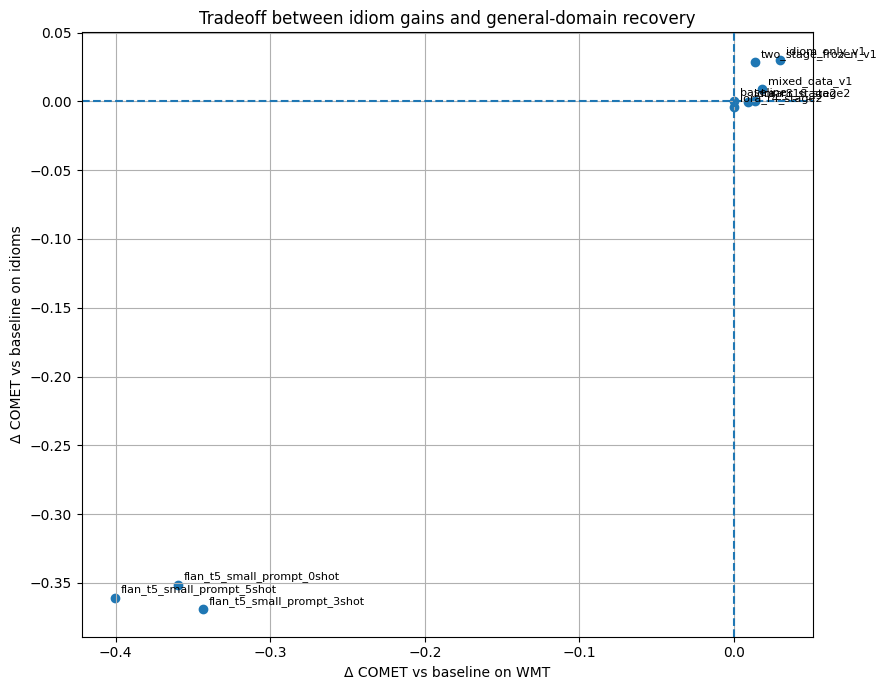

In [12]:
import matplotlib.pyplot as plt

# Suggested Results-section language:
results_language = [
    "Models above zero on the y-axis improve idiom translation relative to the baseline.",
    "Models to the right of zero on the x-axis improve general-domain WMT performance relative to the baseline.",
    "The most desirable region is the upper-right quadrant, which indicates gains on both domains.",
    "Points in the upper-left quadrant reflect the specialization/generalization tradeoff: better idiom handling but worse WMT performance.",
]
for line in results_language:
    print("-", line)

# Prepare tradeoff data from baseline-relative COMET deltas
plot_tradeoff = (
    delta_table
    .pivot(index='model_label', columns='split', values='delta_comet_vs_baseline')
    .reset_index()
    .rename(columns={
        'idioms_test': 'idioms_delta',
        'wmt_test': 'wmt_delta',
    })
)

# Stable model ordering for publication
plot_order = [
    'baseline',
    'idiom_only_v1',
    'two_stage_frozen_v1',
    'mixed_data_v1',
    'lora_r4_stage2',
    'lora_r8_stage2',
    'lora_r16_stage2',
    'flan_t5_small_prompt_0shot',
    'flan_t5_small_prompt_3shot',
    'flan_t5_small_prompt_5shot',
]
plot_tradeoff['order'] = plot_tradeoff['model_label'].map({m: i for i, m in enumerate(plot_order)})
plot_tradeoff = plot_tradeoff.sort_values('order').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(plot_tradeoff['wmt_delta'], plot_tradeoff['idioms_delta'])

for _, row in plot_tradeoff.iterrows():
    ax.annotate(
        row['model_label'],
        (row['wmt_delta'], row['idioms_delta']),
        fontsize=8,
        xytext=(4, 4),
        textcoords='offset points'
    )

ax.axhline(0, linestyle='--')
ax.axvline(0, linestyle='--')

ax.set_xlabel('Δ COMET vs baseline on WMT')
ax.set_ylabel('Δ COMET vs baseline on idioms')
ax.set_title('Tradeoff between idiom gains and general-domain recovery')
ax.grid(True)

plt.tight_layout()
plt.show()


### Split-specific baseline-relative COMET deltas

These bar charts are useful for precise reporting in the Results section because they show the direction and magnitude of COMET change relative to the baseline separately for idioms and WMT.

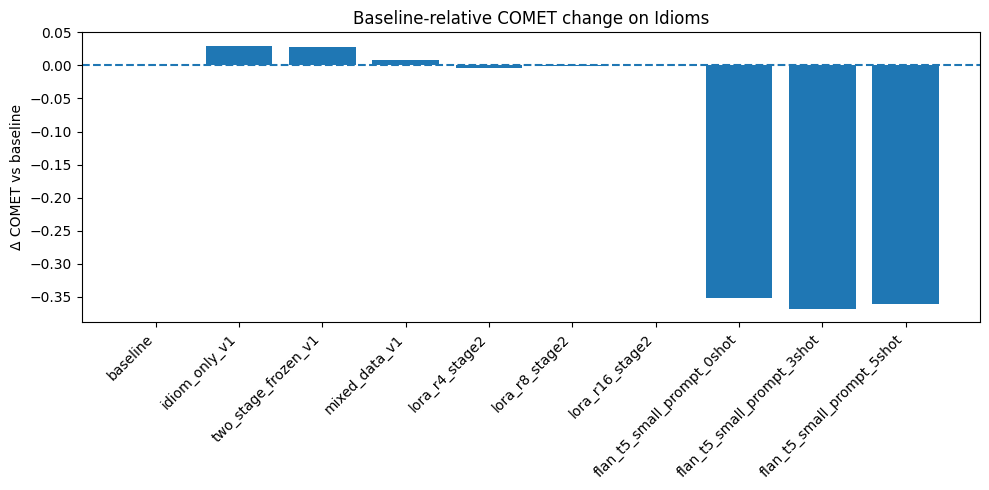

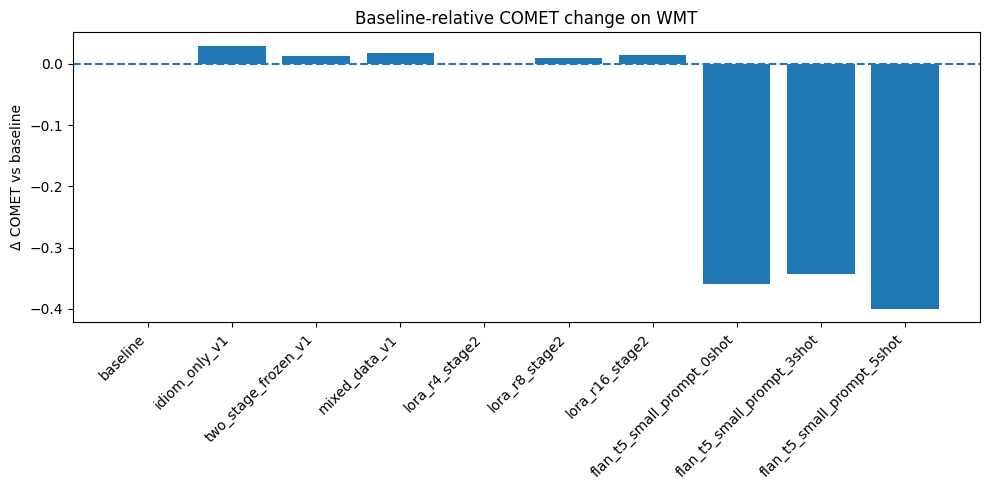

In [13]:
import matplotlib.pyplot as plt

plot_order = [
    'baseline',
    'idiom_only_v1',
    'two_stage_frozen_v1',
    'mixed_data_v1',
    'lora_r4_stage2',
    'lora_r8_stage2',
    'lora_r16_stage2',
    'flan_t5_small_prompt_0shot',
    'flan_t5_small_prompt_3shot',
    'flan_t5_small_prompt_5shot',
]

for split_name, title_suffix in [('idioms_test', 'Idioms'), ('wmt_test', 'WMT')]:
    subset = delta_table[delta_table['split'] == split_name].copy()
    subset['order'] = subset['model_label'].map({m: i for i, m in enumerate(plot_order)})
    subset = subset.sort_values('order').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(subset['model_label'], subset['delta_comet_vs_baseline'])

    ax.axhline(0, linestyle='--')

    ax.set_ylabel('Δ COMET vs baseline')
    ax.set_xlabel('')
    ax.set_title(f'Baseline-relative COMET change on {title_suffix}')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


### Suggested figure caption language

**Tradeoff plot.** "Baseline-relative COMET deltas on idioms and WMT reveal the specialization/generalization tradeoff. Models in the upper-right quadrant improve both domains, whereas models in the upper-left quadrant improve idiom translation while sacrificing general-domain performance."

**Bar charts.** "Baseline-relative COMET changes by split show which adaptation strategies improve idiom translation, which strategies preserve WMT performance, and which models are dominated by the baseline."

## Claim validation and alignment with prior (pre-COMET) results

This section evaluates whether patterns observed in earlier (pre-COMET pipeline) experiments are preserved under COMET-based evaluation. The goal is not to introduce new claims, but to validate consistency between pipelines.

We focus on three comparisons:
1. Idiom-only vs baseline
2. Two-stage vs idiom-only and baseline
3. LoRA vs baseline and two-stage


In [14]:
import pandas as pd

def compare_models(df, models, splits=['idioms_test', 'wmt_test']):
    subset = df[df['model_label'].isin(models) & df['split'].isin(splits)].copy()
    subset = subset.sort_values(['split', 'model_label']).reset_index(drop=True)
    return subset[[
        'model_label', 'split',
        'bleu', 'chrf', 'comet_mean',
        'delta_bleu_vs_baseline',
        'delta_chrf_vs_baseline',
        'delta_comet_vs_baseline'
    ]]

print("=== Idiom-only vs baseline ===")
display(compare_models(delta_table, ['baseline', 'idiom_only_v1']))

print("=== Two-stage vs idiom-only vs baseline ===")
display(compare_models(delta_table, ['baseline', 'idiom_only_v1', 'two_stage_frozen_v1']))

print("=== LoRA vs baseline and two-stage ===")
lora_models = [
    'baseline',
    'two_stage_frozen_v1',
    'lora_r4_stage2',
    'lora_r8_stage2',
    'lora_r16_stage2'
]
display(compare_models(delta_table, lora_models))


=== Idiom-only vs baseline ===


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,baseline,idioms_test,39.649352,60.786112,0.732551,0.000000,0.000000,0.000000
1,idiom_only_v1,idioms_test,44.161210,64.438061,0.762717,4.511858,3.651949,0.030166
2,baseline,wmt_test,27.567994,58.431846,0.833167,0.000000,0.000000,0.000000
3,idiom_only_v1,wmt_test,26.540147,58.230959,0.863072,-1.027847,-0.200887,0.029905


=== Two-stage vs idiom-only vs baseline ===


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,baseline,idioms_test,39.649352,60.786112,0.732551,0.000000,0.000000,0.000000
1,idiom_only_v1,idioms_test,44.161210,64.438061,0.762717,4.511858,3.651949,0.030166
2,two_stage_frozen_v1,idioms_test,43.159787,63.341618,0.760963,3.510435,2.555506,0.028412
3,baseline,wmt_test,27.567994,58.431846,0.833167,0.000000,0.000000,0.000000
4,idiom_only_v1,wmt_test,26.540147,58.230959,0.863072,-1.027847,-0.200887,0.029905
5,two_stage_frozen_v1,wmt_test,27.182381,58.342073,0.846719,-0.385613,-0.089773,0.013552


=== LoRA vs baseline and two-stage ===


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,baseline,idioms_test,39.649352,60.786112,0.732551,0.000000,0.000000,0.000000
1,lora_r16_stage2,idioms_test,41.724245,61.449820,0.732651,2.074893,0.663708,0.000100
2,lora_r4_stage2,idioms_test,41.853197,61.836284,0.728579,2.203845,1.050172,-0.003972
3,lora_r8_stage2,idioms_test,42.178766,61.760909,0.732034,2.529414,0.974797,-0.000517
4,two_stage_frozen_v1,idioms_test,43.159787,63.341618,0.760963,3.510435,2.555506,0.028412
5,baseline,wmt_test,27.567994,58.431846,0.833167,0.000000,0.000000,0.000000
6,lora_r16_stage2,wmt_test,27.596422,58.459373,0.846875,0.028428,0.027528,0.013708
7,lora_r4_stage2,wmt_test,27.568797,58.493063,0.833291,0.000803,0.061217,0.000124
8,lora_r8_stage2,wmt_test,27.480339,58.459796,0.842295,-0.087655,0.027950,0.009128
9,two_stage_frozen_v1,wmt_test,27.182381,58.342073,0.846719,-0.385613,-0.089773,0.013552


### Interpretation guidance

Use these tables to check whether earlier observations still hold:

- If idiom-only improves idioms but reduces WMT, this confirms prior specialization effects.
- If two-stage improves WMT relative to idiom-only, this confirms recovery behavior.
- If LoRA remains closer to baseline on WMT while improving idioms, this supports parameter-efficient tradeoffs.

If results differ from the pre-COMET pipeline, note the discrepancy explicitly in the Results section and attribute differences to metric sensitivity (e.g., COMET vs BLEU/chrF).

### Mixed-data comparison

This small comparison block adds the mixed-data model into the same paper-facing comparison frame. It helps show where mixed-data lands relative to the baseline, idiom-only fine-tuning, and the two-stage model.

In [15]:
print("=== Mixed-data vs baseline vs idiom-only vs two-stage ===")
display(compare_models(delta_table, ['baseline', 'idiom_only_v1', 'two_stage_frozen_v1', 'mixed_data_v1']))


=== Mixed-data vs baseline vs idiom-only vs two-stage ===


,model_label,split,bleu,chrf,comet_mean,delta_bleu_vs_baseline,delta_chrf_vs_baseline,delta_comet_vs_baseline
0,baseline,idioms_test,39.649352,60.786112,0.732551,0.000000,0.000000,0.000000
1,idiom_only_v1,idioms_test,44.161210,64.438061,0.762717,4.511858,3.651949,0.030166
2,mixed_data_v1,idioms_test,43.490413,62.924234,0.741165,3.841061,2.138122,0.008614
3,two_stage_frozen_v1,idioms_test,43.159787,63.341618,0.760963,3.510435,2.555506,0.028412
4,baseline,wmt_test,27.567994,58.431846,0.833167,0.000000,0.000000,0.000000
5,idiom_only_v1,wmt_test,26.540147,58.230959,0.863072,-1.027847,-0.200887,0.029905
6,mixed_data_v1,wmt_test,26.920523,58.095644,0.851503,-0.647471,-0.336201,0.018336
7,two_stage_frozen_v1,wmt_test,27.182381,58.342073,0.846719,-0.385613,-0.089773,0.013552


## Claim checks

**What this section does:**  
This section turns major hypotheses from the earlier, pre-COMET interpretation into explicit TRUE/FALSE checks under the current COMET-based evaluation.

**What to look for:**  
A TRUE result means the earlier expectation still holds under COMET. A FALSE result means the earlier conclusion changed once semantic evaluation was introduced.

**What it means for the paper:**  
This section helps us separate stable findings from revised findings. It is especially useful for showing where the original LoRA / catastrophic-forgetting narrative no longer matches the updated evaluation.


In [16]:
WMT_TOL = -0.01

def get_metric_delta(model_label: str, split: str, col: str = 'delta_comet_vs_baseline'):
    row = delta_table[(delta_table['model_label'] == model_label) & (delta_table['split'] == split)]
    if row.empty:
        raise ValueError(f'Missing row for model={model_label}, split={split}')
    return float(row.iloc[0][col])

def get_metric_value(model_label: str, split: str, col: str = 'comet_mean'):
    row = delta_table[(delta_table['model_label'] == model_label) & (delta_table['split'] == split)]
    if row.empty:
        raise ValueError(f'Missing row for model={model_label}, split={split}')
    return float(row.iloc[0][col])

claim_rows = []

# 1. Idiom-only specialization pattern
idiom_only_idiom_delta = get_metric_delta('idiom_only_v1', 'idioms_test')
idiom_only_wmt_delta = get_metric_delta('idiom_only_v1', 'wmt_test')

claim_rows.append({
    'claim_group': 'Idiom-only specialization',
    'claim': 'Idiom-only improves idioms vs baseline',
    'check_type': 'delta > 0',
    'value_used': idiom_only_idiom_delta,
    'result': idiom_only_idiom_delta > 0,
    'explanation': 'A positive idioms_test COMET delta means idiom-only fine-tuning improves idiom translation relative to the baseline.'
})

claim_rows.append({
    'claim_group': 'Idiom-only specialization',
    'claim': 'Idiom-only hurts WMT vs baseline',
    'check_type': 'delta < 0',
    'value_used': idiom_only_wmt_delta,
    'result': idiom_only_wmt_delta < 0,
    'explanation': 'A negative wmt_test COMET delta means idiom-only fine-tuning degrades general-domain performance relative to the baseline.'
})

# 2. Two-stage recovery pattern
two_stage_wmt = get_metric_value('two_stage_frozen_v1', 'wmt_test')
idiom_only_wmt = get_metric_value('idiom_only_v1', 'wmt_test')
two_stage_idiom_delta = get_metric_delta('two_stage_frozen_v1', 'idioms_test')

claim_rows.append({
    'claim_group': 'Two-stage recovery',
    'claim': 'Two-stage improves WMT vs idiom-only',
    'check_type': 'two_stage_frozen_v1 COMET > idiom_only_v1 COMET',
    'value_used': two_stage_wmt - idiom_only_wmt,
    'result': two_stage_wmt > idiom_only_wmt,
    'explanation': 'If two-stage WMT COMET exceeds idiom-only WMT COMET, this supports the idea that the second stage recovers general-domain performance.'
})

claim_rows.append({
    'claim_group': 'Two-stage recovery',
    'claim': 'Two-stage retains positive idiom gains vs baseline',
    'check_type': 'delta > 0',
    'value_used': two_stage_idiom_delta,
    'result': two_stage_idiom_delta > 0,
    'explanation': 'A positive idioms_test COMET delta means the two-stage model still improves idiom translation relative to the baseline.'
})

# 3. LoRA tradeoff pattern
for model in ['lora_r4_stage2', 'lora_r8_stage2', 'lora_r16_stage2']:
    idiom_delta = get_metric_delta(model, 'idioms_test')
    wmt_delta = get_metric_delta(model, 'wmt_test')

    claim_rows.append({
        'claim_group': 'LoRA tradeoff',
        'claim': f'{model} improves idioms vs baseline',
        'check_type': 'delta > 0',
        'value_used': idiom_delta,
        'result': idiom_delta > 0,
        'explanation': 'A positive idioms_test COMET delta means this LoRA model improves idiom translation relative to the baseline.'
    })

    claim_rows.append({
        'claim_group': 'LoRA tradeoff',
        'claim': f'{model} preserves WMT near baseline',
        'check_type': f'delta >= {WMT_TOL}',
        'value_used': wmt_delta,
        'result': wmt_delta >= WMT_TOL,
        'explanation': 'Using a small tolerance allows near-baseline WMT performance to count as preserved, rather than treating tiny metric changes as meaningful degradation.'
    })

claim_checks = pd.DataFrame(claim_rows)

display(claim_checks[['claim_group', 'claim', 'check_type', 'value_used', 'result']])

print('Expanded explanations:')
display(claim_checks[['claim', 'explanation']])


,claim_group,claim,check_type,value_used,result
0,Idiom-only specialization,Idiom-only improves idioms vs baseline,delta > 0,0.030166,True
1,Idiom-only specialization,Idiom-only hurts WMT vs baseline,delta < 0,0.029905,False
2,Two-stage recovery,Two-stage improves WMT vs idiom-only,two_stage_frozen_v1 COMET > idiom_only_v1 COMET,-0.016353,False
3,Two-stage recovery,Two-stage retains positive idiom gains vs base...,delta > 0,0.028412,True
4,LoRA tradeoff,lora_r4_stage2 improves idioms vs baseline,delta > 0,-0.003972,False
5,LoRA tradeoff,lora_r4_stage2 preserves WMT near baseline,delta >= -0.01,0.000124,True
6,LoRA tradeoff,lora_r8_stage2 improves idioms vs baseline,delta > 0,-0.000517,False
7,LoRA tradeoff,lora_r8_stage2 preserves WMT near baseline,delta >= -0.01,0.009128,True
8,LoRA tradeoff,lora_r16_stage2 improves idioms vs baseline,delta > 0,0.000100,True
9,LoRA tradeoff,lora_r16_stage2 preserves WMT near baseline,delta >= -0.01,0.013708,True


Expanded explanations:


,claim,explanation
0,Idiom-only improves idioms vs baseline,A positive idioms_test COMET delta means idiom...
1,Idiom-only hurts WMT vs baseline,A negative wmt_test COMET delta means idiom-on...
2,Two-stage improves WMT vs idiom-only,If two-stage WMT COMET exceeds idiom-only WMT ...
3,Two-stage retains positive idiom gains vs base...,A positive idioms_test COMET delta means the t...
4,lora_r4_stage2 improves idioms vs baseline,A positive idioms_test COMET delta means this ...
5,lora_r4_stage2 preserves WMT near baseline,Using a small tolerance allows near-baseline W...
6,lora_r8_stage2 improves idioms vs baseline,A positive idioms_test COMET delta means this ...
7,lora_r8_stage2 preserves WMT near baseline,Using a small tolerance allows near-baseline W...
8,lora_r16_stage2 improves idioms vs baseline,A positive idioms_test COMET delta means this ...
9,lora_r16_stage2 preserves WMT near baseline,Using a small tolerance allows near-baseline W...


### How to read these checks

These checks are meant to support the Results section language directly.

- A **TRUE** result means the current COMET pipeline is consistent with the earlier observed pattern.
- A **FALSE** result means the COMET pipeline does not support the earlier pattern as currently phrased, and the paper should be updated to reflect that.
- The `value_used` column shows the numeric quantity behind the decision so that the binary flag does not hide the underlying magnitude.

These checks are intentionally selective. They focus on the central empirical patterns rather than constructing a full comparison matrix across every model pair.

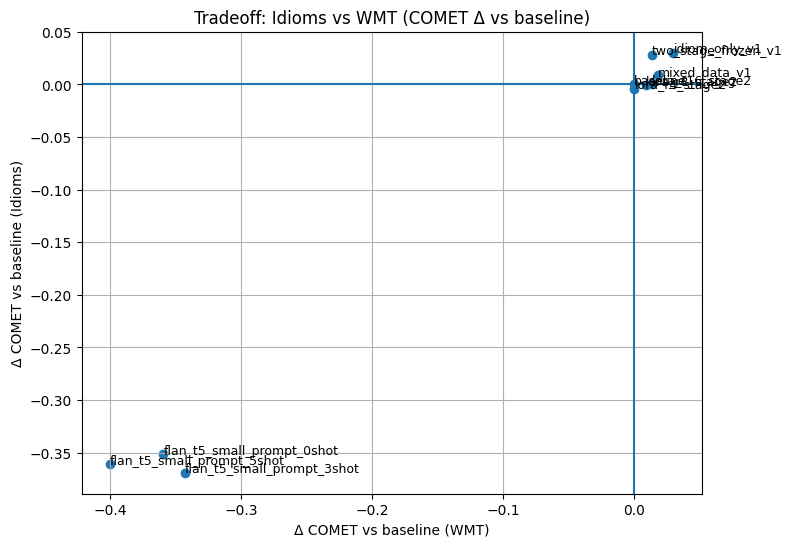

In [17]:
# Pivot so each model has idioms + wmt deltas in one row
pivot = (
    delta_table
    .pivot(index='model_label', columns='split', values='delta_comet_vs_baseline')
    .reset_index()
    .rename(columns={
        'idioms_test': 'idioms_delta',
        'wmt_test': 'wmt_delta'
    })
)

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(pivot['wmt_delta'], pivot['idioms_delta'])

# Label each point
for _, row in pivot.iterrows():
    plt.text(row['wmt_delta'], row['idioms_delta'], row['model_label'], fontsize=9)

# Reference lines (baseline = 0)
plt.axhline(0)
plt.axvline(0)

plt.xlabel('Δ COMET vs baseline (WMT)')
plt.ylabel('Δ COMET vs baseline (Idioms)')
plt.title('Tradeoff: Idioms vs WMT (COMET Δ vs baseline)')

plt.grid(True)
plt.show()

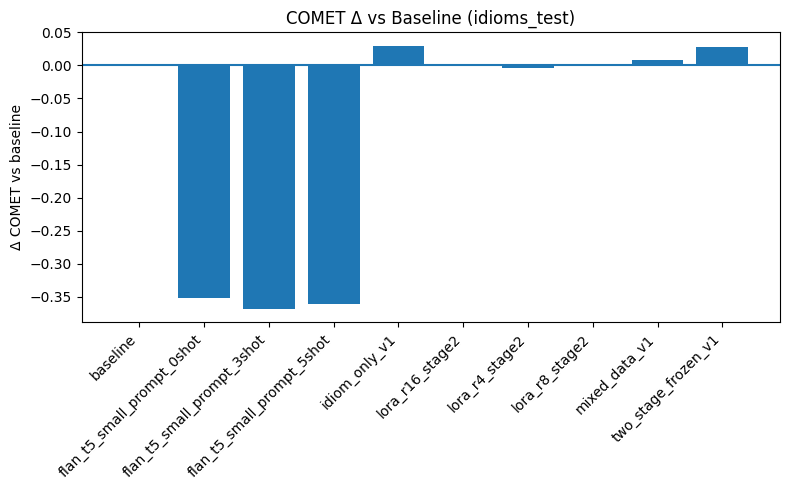

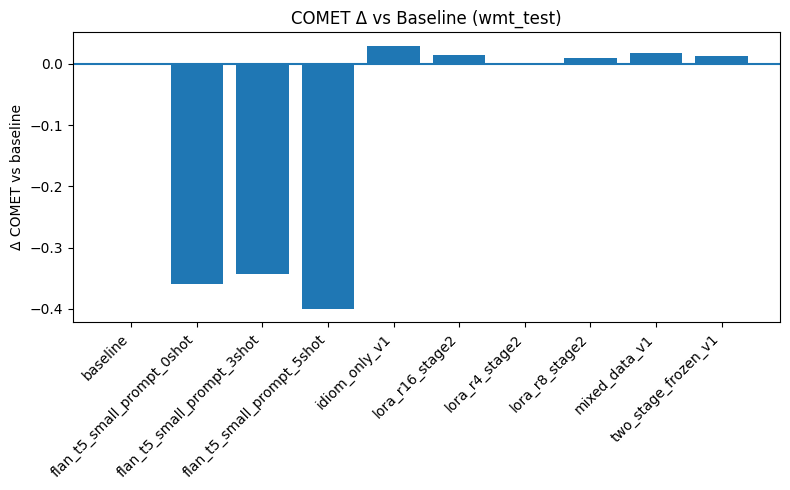

In [18]:
import matplotlib.pyplot as plt

for split_name in ['idioms_test', 'wmt_test']:
    subset = delta_table[delta_table['split'] == split_name]

    plt.figure(figsize=(8, 5))
    plt.bar(subset['model_label'], subset['delta_comet_vs_baseline'])

    plt.axhline(0)

    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Δ COMET vs baseline')
    plt.title(f'COMET Δ vs Baseline ({split_name})')

    plt.tight_layout()
    plt.show()

## 6. FLAN variant comparison

This section compares FLAN 0-shot, 3-shot, and 5-shot across the two evaluation groups. The goal is to justify the single FLAN variant later selected for human annotation.

In [19]:
flan_by_group = summary_by_group[summary_by_group['model'].str.contains('flan_t5_small_prompt')].copy()
flan_overall = summary_overall[summary_overall['model'].str.contains('flan_t5_small_prompt')].copy()
flan_merged = merged_metrics[merged_metrics['model_label'].str.contains('flan_t5_small_prompt')].copy()

print('FLAN by group:')
display(flan_by_group.sort_values(['group', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))

print('FLAN overall:')
display(flan_overall.sort_values('comet_mean', ascending=False).reset_index(drop=True))

print('FLAN merged metrics:')
display(flan_merged.sort_values(['split', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))


FLAN by group:


,model,group,n,comet_mean,comet_std,input_sources
0,flan_t5_small_prompt_0shot,idioms_test,25,0.381018,0.118532,per_model_csvs
1,flan_t5_small_prompt_5shot,idioms_test,25,0.371568,0.127203,per_model_csvs
2,flan_t5_small_prompt_3shot,idioms_test,25,0.363405,0.106758,per_model_csvs
3,flan_t5_small_prompt_3shot,wmt_test,25,0.489949,0.153432,per_model_csvs
4,flan_t5_small_prompt_0shot,wmt_test,25,0.473576,0.138647,per_model_csvs
5,flan_t5_small_prompt_5shot,wmt_test,25,0.432660,0.142552,per_model_csvs


FLAN overall:


,model,n,comet_mean,comet_std,input_sources
0,flan_t5_small_prompt_0shot,50,0.427297,0.135950,per_model_csvs
1,flan_t5_small_prompt_3shot,50,0.426677,0.145595,per_model_csvs
2,flan_t5_small_prompt_5shot,50,0.402114,0.137224,per_model_csvs


FLAN merged metrics:


,model_label,split,comet_mean,comet_std,n,bleu,chrf,metrics_source_file
0,flan_t5_small_prompt_0shot,idioms_test,0.381018,0.118532,25,8.126810,33.138795,automatic_metrics_canonical.csv
1,flan_t5_small_prompt_5shot,idioms_test,0.371568,0.127203,25,7.623039,32.096459,automatic_metrics_canonical.csv
2,flan_t5_small_prompt_3shot,idioms_test,0.363405,0.106758,25,7.769178,32.517583,automatic_metrics_canonical.csv
3,flan_t5_small_prompt_3shot,wmt_test,0.489949,0.153432,25,7.431623,36.224973,automatic_metrics_canonical.csv
4,flan_t5_small_prompt_0shot,wmt_test,0.473576,0.138647,25,7.615428,35.542535,automatic_metrics_canonical.csv
5,flan_t5_small_prompt_5shot,wmt_test,0.432660,0.142552,25,4.958042,29.858081,automatic_metrics_canonical.csv


### Interim interpretation

Use this section to record which FLAN variant performs best on idioms, which performs best on WMT, and which one should be used for the blinded annotation package.

## 7. Tradeoff analysis across models

This section compares idiom performance against WMT performance to examine the specialization vs generalization tradeoff.

In [20]:
tradeoff = summary_by_group.pivot(index='model', columns='group', values='comet_mean').reset_index()
tradeoff.columns.name = None
tradeoff = tradeoff.rename(columns={
    'idioms_test': 'idioms_comet',
    'wmt_test': 'wmt_comet'
})

baseline_idioms = tradeoff.loc[tradeoff['model'] == 'baseline', 'idioms_comet'].iloc[0]
baseline_wmt = tradeoff.loc[tradeoff['model'] == 'baseline', 'wmt_comet'].iloc[0]

tradeoff['idioms_vs_baseline'] = tradeoff['idioms_comet'] - baseline_idioms
tradeoff['wmt_vs_baseline'] = tradeoff['wmt_comet'] - baseline_wmt

display(tradeoff.sort_values('idioms_comet', ascending=False).reset_index(drop=True))


,model,idioms_comet,wmt_comet,idioms_vs_baseline,wmt_vs_baseline
0,idiom_only_v1,0.762717,0.863072,0.030166,0.029905
1,two_stage_frozen_v1,0.760963,0.846719,0.028412,0.013552
2,mixed_data_v1,0.741165,0.851503,0.008614,0.018336
3,lora_r16_stage2,0.732651,0.846875,0.000100,0.013708
4,baseline,0.732551,0.833167,0.000000,0.000000
5,lora_r8_stage2,0.732034,0.842295,-0.000517,0.009128
6,lora_r4_stage2,0.728579,0.833291,-0.003972,0.000124
7,flan_t5_small_prompt_0shot,0.381018,0.473576,-0.351533,-0.359591
8,flan_t5_small_prompt_5shot,0.371568,0.432660,-0.360983,-0.400507
9,flan_t5_small_prompt_3shot,0.363405,0.489949,-0.369146,-0.343217


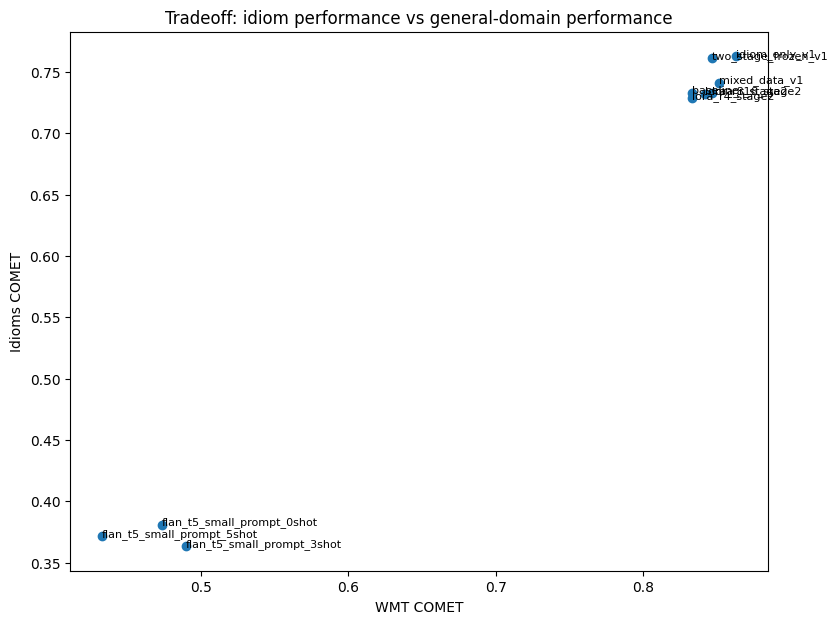

In [21]:
plot_df = tradeoff.copy()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(plot_df['wmt_comet'], plot_df['idioms_comet'])

for _, row in plot_df.iterrows():
    ax.annotate(row['model'], (row['wmt_comet'], row['idioms_comet']), fontsize=8)

ax.set_xlabel('WMT COMET')
ax.set_ylabel('Idioms COMET')
ax.set_title('Tradeoff: idiom performance vs general-domain performance')
plt.show()


## 8. Sentence-level qualitative analysis

This section uses sentence-level spread to identify examples where the models disagree most strongly. These are often the best candidates for qualitative discussion in the paper.

In [22]:
high_spread = spread.sort_values('comet_spread', ascending=False).head(10)
display(high_spread[['group', 'src', 'ref', 'comet_min', 'comet_max', 'comet_spread']])

,group,src,ref,comet_min,comet_max,comet_spread
0,idioms_test,But before she could launch her charm offensiv...,Doch bevor sie ihre Charmeoffensive starten ko...,0.169645,0.945956,0.776311
1,idioms_test,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",0.282064,0.917172,0.635108
2,idioms_test,"For the young Canadian servicemen, the order t...",Die jungen kanadischen Soldaten erwarteten täg...,0.180694,0.812785,0.632091
25,wmt_test,"However, if no new orders are announced in the...",Falls allerdings in den kommenden Monaten kein...,0.295748,0.918535,0.622787
26,wmt_test,"Meanwhile, U.S. lawmakers will head to Europe ...",Unterdessen werden US-amerikanische Gesetzgebe...,0.267089,0.889408,0.622318
27,wmt_test,All three face a maximum penalty of life impri...,Allen dreien droht als Höchststrafe lebenslang...,0.271974,0.889371,0.617396
28,wmt_test,"""Decisions will then be made elsewhere,"" said ...","""Dann werden Entscheidungen an anderer Stelle ...",0.333581,0.943284,0.609703
29,wmt_test,Howie was also ordered to pay costs of £90 and...,Howie wurde außerdem zur Zahlung von Kosten in...,0.319074,0.908975,0.589901
3,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",0.290774,0.876986,0.586211
4,idioms_test,We're cut from the same cloth as any American ...,Wir sind aus dem gleichen Holz geschnitzt wie ...,0.336061,0.907208,0.571148


### Example inspection helper

Use this cell to inspect all model outputs for a selected sentence.

In [23]:
example_idx = 0  # change this to inspect different rows from high_spread
row = high_spread.iloc[example_idx]

print('GROUP:', row['group'])
print('SRC:', row['src'])
print('REF:', row['ref'])
print('\nModel outputs:')

model_cols = [c for c in spread.columns if c not in ['src', 'ref', 'group', 'comet_min', 'comet_max', 'comet_spread']]
for c in model_cols:
    print(f'\n[{c}]\n{row[c]}')

GROUP: idioms_test
SRC: But before she could launch her charm offensive, Mr. Roper sat down across from her and grabbed her wrists.
REF: Doch bevor sie ihre Charmeoffensive starten konnte, setzte sich Herr Roper ihr gegenüber und packte ihre Handgelenke.

Model outputs:

[baseline]
0.9326590895652772

[flan_t5_small_prompt_0shot]
0.2525595128536224

[flan_t5_small_prompt_3shot]
0.1696445345878601

[flan_t5_small_prompt_5shot]
0.1696445345878601

[idiom_only_v1]
0.8637920618057251

[lora_r16_stage2]
0.9326590895652772

[lora_r4_stage2]
0.9459559917449952

[lora_r8_stage2]
0.9326590895652772

[mixed_data_v1]
0.760520339012146

[two_stage_frozen_v1]
0.9282024502754213


## 9. Candidate model selection for human evaluation

The final six-model annotation set should be documented here once the FLAN selection decision is locked.

In [24]:
annotation_models = [
    'baseline',
    'idiom_only_v1',
    'lora_r4_stage2',
    'lora_r8_stage2',
    'lora_r16_stage2',
    'flan_t5_small_prompt_0shot',
]

pd.DataFrame({'annotation_model_set': annotation_models})

,annotation_model_set
0,baseline
1,idiom_only_v1
2,lora_r4_stage2
3,lora_r8_stage2
4,lora_r16_stage2
5,flan_t5_small_prompt_0shot


## 10. Human evaluation (placeholder)

Human evaluation results will be integrated here once annotation is complete. A separate notebook will handle unblinding, summary statistics, and confidence intervals, and the resulting outputs will be summarized back into this notebook.

## 11. Interim conclusions

Use this section to summarize what is already supported by automatic evaluation and what still awaits human validation.

In [25]:
interim_points = [
    'Automatic metrics and COMET are now merged into results/automatic_plus_comet.csv.',
    'Notebook 30 is now the source of the COMET-based evaluation outputs.',
    'The main evaluated model set now includes mixed_data_v1 in addition to baseline, idiom-only, two-stage, LoRA, and FLAN prompting variants.',
    'Notebook 21 still uses the fixed 6-model human-eval packet and is intentionally not changed by the mixed-data addition.',
    'Notebook 11 is using the current merged and sentence-level files and is being expanded into the main paper-facing analysis notebook.',
]

for p in interim_points:
    print('-', p)


- Automatic metrics and COMET are now merged into results/automatic_plus_comet.csv.
- Notebook 30 is now the source of the COMET-based evaluation outputs.
- The main evaluated model set now includes mixed_data_v1 in addition to baseline, idiom-only, two-stage, LoRA, and FLAN prompting variants.
- Notebook 21 still uses the fixed 6-model human-eval packet and is intentionally not changed by the mixed-data addition.
- Notebook 11 is using the current merged and sentence-level files and is being expanded into the main paper-facing analysis notebook.


# Quick Santify check

In [26]:
print("merged_metrics shape:", merged_metrics.shape)
display(merged_metrics.groupby(["model_label", "split"]).size().rename("n_rows").reset_index())

print("Models in merged_metrics:")
display(pd.Series(sorted(merged_metrics["model_label"].unique()), name="model_label"))

merged_metrics shape: (20, 8)


,model_label,split,n_rows
0,baseline,idioms_test,1
1,baseline,wmt_test,1
2,flan_t5_small_prompt_0shot,idioms_test,1
3,flan_t5_small_prompt_0shot,wmt_test,1
4,flan_t5_small_prompt_3shot,idioms_test,1
5,flan_t5_small_prompt_3shot,wmt_test,1
6,flan_t5_small_prompt_5shot,idioms_test,1
7,flan_t5_small_prompt_5shot,wmt_test,1
8,idiom_only_v1,idioms_test,1
9,idiom_only_v1,wmt_test,1


Models in merged_metrics:


,model_label
0,baseline
1,flan_t5_small_prompt_0shot
2,flan_t5_small_prompt_3shot
3,flan_t5_small_prompt_5shot
4,idiom_only_v1
5,lora_r16_stage2
6,lora_r4_stage2
7,lora_r8_stage2
8,mixed_data_v1
9,two_stage_frozen_v1


## Final summary

**What this section does:**  
This section condenses the notebook into a short list of paper-ready conclusions.

**What to look for:**  
Identify the best model on idioms, the best model on WMT, the best overall model, and where mixed-data and LoRA land relative to idiom-only and two-stage.

**What it means for the paper:**  
This is the bridge from notebook analysis to paper writing. The Results section should largely be built from the findings summarized here.


In [27]:
# Compute summary
import numpy as np

pivot = merged_metrics.pivot(index='model_label', columns='split', values='comet_mean').reset_index()
pivot['overall_mean'] = pivot[['idioms_test','wmt_test']].mean(axis=1)

best_idiom = pivot.sort_values('idioms_test', ascending=False).iloc[0]
best_wmt = pivot.sort_values('wmt_test', ascending=False).iloc[0]
best_overall = pivot.sort_values('overall_mean', ascending=False).iloc[0]

print("Best idiom model:", best_idiom['model_label'], best_idiom['idioms_test'])
print("Best WMT model:", best_wmt['model_label'], best_wmt['wmt_test'])
print("Best overall model:", best_overall['model_label'], best_overall['overall_mean'])

display(pivot.sort_values('overall_mean', ascending=False))


Best idiom model: idiom_only_v1 0.7627165985107421
Best WMT model: idiom_only_v1 0.8630717396736145
Best overall model: idiom_only_v1 0.8128941690921783


split,model_label,idioms_test,wmt_test,overall_mean
4,idiom_only_v1,0.762717,0.863072,0.812894
9,two_stage_frozen_v1,0.760963,0.846719,0.803841
8,mixed_data_v1,0.741165,0.851503,0.796334
5,lora_r16_stage2,0.732651,0.846875,0.789763
7,lora_r8_stage2,0.732034,0.842295,0.787165
0,baseline,0.732551,0.833167,0.782859
6,lora_r4_stage2,0.728579,0.833291,0.780935
1,flan_t5_small_prompt_0shot,0.381018,0.473576,0.427297
2,flan_t5_small_prompt_3shot,0.363405,0.489949,0.426677
3,flan_t5_small_prompt_5shot,0.371568,0.432660,0.402114


## Qualitative examples

**What this section does:**  
This section shows actual model translations for selected examples so that we can inspect differences that summary metrics alone cannot explain.

**What to look for:**  
Look for cases where models differ in semantic adequacy, idiomaticity, fluency, or literalness. These examples are especially useful when the ranking changes across metrics.

**What it means for the paper:**  
This section gives us concrete examples to support the Results discussion. It helps explain *why* a model that looked strong under BLEU/chrF may look weaker under COMET, and vice versa.


In [28]:
# Show actual predictions instead of scores
example_idx = 0
row = high_spread.iloc[example_idx]

print("SRC:", row['src'])
print("REF:", row['ref'])

models_to_show = ['baseline','idiom_only_v1','mixed_data_v1','two_stage_frozen_v1','lora_r8_stage2','flan_t5_small_prompt_0shot']

subset = scores[(scores['src']==row['src']) & (scores['group']==row['group'])]

for m in models_to_show:
    pred = subset[subset['model']==m]['pred'].values
    if len(pred)>0:
        print(f"\n[{m}]\n{pred[0]}")


SRC: But before she could launch her charm offensive, Mr. Roper sat down across from her and grabbed her wrists.
REF: Doch bevor sie ihre Charmeoffensive starten konnte, setzte sich Herr Roper ihr gegenüber und packte ihre Handgelenke.

[baseline]
Aber bevor sie ihre Charmeoffensive starten konnte, setzte sich Mr. Roper ihr gegenüber und packte ihre Handgelenke.

[idiom_only_v1]
Aber bevor sie ihre Charmeoffensive starten konnte, setzte sich Herr Roper ihr gegenüber und packte sich die Arme.

[mixed_data_v1]
Aber bevor sie ihre Charmeoffensive starten konnte, setzte sich Herr Roper ihr gegenüber und packte sich die Pulsadern.

[two_stage_frozen_v1]
Aber bevor sie ihre Charmeoffensive starten konnte, setzte sich Herr Roper ihr gegenüber und packte ihr die Handgelenke.

[lora_r8_stage2]
Aber bevor sie ihre Charmeoffensive starten konnte, setzte sich Mr. Roper ihr gegenüber und packte ihre Handgelenke.

[flan_t5_small_prompt_0shot]
Aber bevor er es er stört, er Herr Roper störtte störtte 

## Human-eval status

**What this section does:**  
This section records the status of human evaluation and clarifies how it relates to the automatic evaluation pipeline.

**What to look for:**  
The important point is that the human-eval packet is frozen and still uses the original fixed six-model set. Mixed-data was added only to automatic evaluation.

**What it means for the paper:**  
This lets the paper clearly distinguish between the automatic comparison set and the human-eval subset, without implying that the annotation packet was rebuilt.


## 12. Paper-facing automatic-evaluation support

This section creates paper-ready tables, figure-ready datasets, curated qualitative example exports, and saved figures for the final report and presentation. It does **not** recompute the upstream automatic metrics. It only reshapes the finalized notebook outputs into artifacts that are easier to use in the paper.


In [29]:

# Paper-facing labels, split names, and export directory
from pathlib import Path
import pandas as pd
import numpy as np

PAPER_EXPORT_DIR = RESULTS_DIR / 'automatic_eval_outputs'
PAPER_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DISPLAY_MAP = {
    'baseline': 'Baseline',
    'idiom_only_v1': 'Idiom-only FT',
    'two_stage_frozen_v1': 'Two-stage FT',
    'mixed_data_v1': 'Mixed-data FT',
    'lora_r4_stage2': 'LoRA r=4',
    'lora_r8_stage2': 'LoRA r=8',
    'lora_r16_stage2': 'LoRA r=16',
    'flan_t5_small_prompt_0shot': 'FLAN 0-shot',
    'flan_t5_small_prompt_3shot': 'FLAN 3-shot',
    'flan_t5_small_prompt_5shot': 'FLAN 5-shot',
}

MODEL_ORDER = [
    'Baseline',
    'Idiom-only FT',
    'Two-stage FT',
    'Mixed-data FT',
    'LoRA r=4',
    'LoRA r=8',
    'LoRA r=16',
    'FLAN 0-shot',
    'FLAN 3-shot',
    'FLAN 5-shot',
]

SPLIT_DISPLAY_MAP = {
    'idioms_test': 'Idioms',
    'wmt_test': 'WMT',
    'idioms': 'Idioms',
    'wmt': 'WMT',
}

analysis_display = merged_metrics.copy()
analysis_display['model'] = analysis_display['model_label'].map(MODEL_DISPLAY_MAP).fillna(analysis_display['model_label'])
analysis_display['split'] = analysis_display['split'].map(SPLIT_DISPLAY_MAP).fillna(analysis_display['split'])
analysis_display['model'] = pd.Categorical(analysis_display['model'], categories=MODEL_ORDER, ordered=True)
analysis_display['split'] = pd.Categorical(analysis_display['split'], categories=['Idioms', 'WMT'], ordered=True)

display(
    analysis_display.sort_values(['split', 'comet_mean'], ascending=[True, False]).reset_index(drop=True)
)
print('Paper export directory:', PAPER_EXPORT_DIR)


,model_label,split,comet_mean,comet_std,n,bleu,chrf,metrics_source_file,model
0,idiom_only_v1,Idioms,0.762717,0.133694,25,44.161210,64.438061,automatic_metrics_canonical.csv,Idiom-only FT
1,two_stage_frozen_v1,Idioms,0.760963,0.135645,25,43.159787,63.341618,automatic_metrics_canonical.csv,Two-stage FT
2,mixed_data_v1,Idioms,0.741165,0.146571,25,43.490413,62.924234,metrics.csv,Mixed-data FT
3,lora_r16_stage2,Idioms,0.732651,0.143304,25,41.724245,61.449820,automatic_metrics_canonical.csv,LoRA r=16
4,baseline,Idioms,0.732551,0.135192,25,39.649352,60.786112,automatic_metrics_canonical.csv,Baseline
5,lora_r8_stage2,Idioms,0.732034,0.147128,25,42.178766,61.760909,automatic_metrics_canonical.csv,LoRA r=8
6,lora_r4_stage2,Idioms,0.728579,0.152061,25,41.853197,61.836284,automatic_metrics_canonical.csv,LoRA r=4
7,flan_t5_small_prompt_0shot,Idioms,0.381018,0.118532,25,8.126810,33.138795,automatic_metrics_canonical.csv,FLAN 0-shot
8,flan_t5_small_prompt_5shot,Idioms,0.371568,0.127203,25,7.623039,32.096459,automatic_metrics_canonical.csv,FLAN 5-shot
9,flan_t5_small_prompt_3shot,Idioms,0.363405,0.106758,25,7.769178,32.517583,automatic_metrics_canonical.csv,FLAN 3-shot


Paper export directory: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs


## 13. Build paper-ready tables

These tables are narrower and more presentation-friendly than the exploratory notebook displays. They are intended to support:
- the main automatic-results table
- the metric-choice / ranking-shift story
- the tradeoff summary around idiom gains versus general-domain performance


In [30]:

# Paper table 1: automatic metrics by split with explicit ranks
paper_table_automatic_by_split = analysis_display.copy()

for metric in ['bleu', 'chrf', 'comet_mean']:
    paper_table_automatic_by_split[f'{metric}_rank'] = (
        paper_table_automatic_by_split.groupby('split')[metric]
        .rank(method='dense', ascending=False)
        .astype(int)
    )

paper_table_automatic_by_split = paper_table_automatic_by_split[[
    'model', 'split',
    'bleu', 'bleu_rank',
    'chrf', 'chrf_rank',
    'comet_mean', 'comet_mean_rank'
]].sort_values(['split', 'comet_mean_rank', 'bleu_rank', 'chrf_rank']).reset_index(drop=True)

# Paper table 2: metric-ranking comparison with explicit rank shifts
paper_table_metric_rankings = paper_table_automatic_by_split.copy()
paper_table_metric_rankings['overlap_metric_rank_mean'] = (
    paper_table_metric_rankings[['bleu_rank', 'chrf_rank']].mean(axis=1)
)
paper_table_metric_rankings['comet_rank_shift_vs_overlap'] = (
    paper_table_metric_rankings['comet_mean_rank'] - paper_table_metric_rankings['overlap_metric_rank_mean']
)

paper_table_metric_rankings = paper_table_metric_rankings[[
    'model', 'split',
    'bleu_rank', 'chrf_rank', 'comet_mean_rank',
    'overlap_metric_rank_mean', 'comet_rank_shift_vs_overlap'
]].sort_values(['split', 'comet_mean_rank', 'bleu_rank']).reset_index(drop=True)

# Paper table 3: baseline-relative tradeoff summary
baseline_rows_display = (
    analysis_display[analysis_display['model'] == 'Baseline'][['split', 'bleu', 'chrf', 'comet_mean']]
    .rename(columns={
        'bleu': 'baseline_bleu',
        'chrf': 'baseline_chrf',
        'comet_mean': 'baseline_comet',
    })
)

paper_tradeoff_long = (
    analysis_display.merge(baseline_rows_display, on='split', how='left')
    .assign(
        delta_bleu_vs_baseline=lambda d: d['bleu'] - d['baseline_bleu'],
        delta_chrf_vs_baseline=lambda d: d['chrf'] - d['baseline_chrf'],
        delta_comet_vs_baseline=lambda d: d['comet_mean'] - d['baseline_comet'],
    )
)

paper_table_tradeoff_summary = (
    paper_tradeoff_long
    .pivot(index='model', columns='split', values=[
        'delta_bleu_vs_baseline',
        'delta_chrf_vs_baseline',
        'delta_comet_vs_baseline'
    ])
)

paper_table_tradeoff_summary.columns = [
    f"{metric.replace('delta_', '').replace('_vs_baseline', '')}_{split}"
    for metric, split in paper_table_tradeoff_summary.columns
]
paper_table_tradeoff_summary = (
    paper_table_tradeoff_summary
    .reset_index()
    .sort_values('comet_Idioms', ascending=False)
    .reset_index(drop=True)
)

display(paper_table_automatic_by_split)
display(paper_table_metric_rankings)
display(paper_table_tradeoff_summary)


/tmp/ipykernel_8158/2619224512.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paper_table_automatic_by_split.groupby('split')[metric]
/tmp/ipykernel_8158/2619224512.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paper_table_automatic_by_split.groupby('split')[metric]
/tmp/ipykernel_8158/2619224512.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paper_table_automatic_by_split.groupby('split')[metric]


,model,split,bleu,bleu_rank,chrf,chrf_rank,comet_mean,comet_mean_rank
0,Idiom-only FT,Idioms,44.161210,1,64.438061,1,0.762717,1
1,Two-stage FT,Idioms,43.159787,3,63.341618,2,0.760963,2
2,Mixed-data FT,Idioms,43.490413,2,62.924234,3,0.741165,3
3,LoRA r=16,Idioms,41.724245,6,61.449820,6,0.732651,4
4,Baseline,Idioms,39.649352,7,60.786112,7,0.732551,5
5,LoRA r=8,Idioms,42.178766,4,61.760909,5,0.732034,6
6,LoRA r=4,Idioms,41.853197,5,61.836284,4,0.728579,7
7,FLAN 0-shot,Idioms,8.126810,8,33.138795,8,0.381018,8
8,FLAN 5-shot,Idioms,7.623039,10,32.096459,10,0.371568,9
9,FLAN 3-shot,Idioms,7.769178,9,32.517583,9,0.363405,10


,model,split,bleu_rank,chrf_rank,comet_mean_rank,overlap_metric_rank_mean,comet_rank_shift_vs_overlap
0,Idiom-only FT,Idioms,1,1,1,1.0,0.0
1,Two-stage FT,Idioms,3,2,2,2.5,-0.5
2,Mixed-data FT,Idioms,2,3,3,2.5,0.5
3,LoRA r=16,Idioms,6,6,4,6.0,-2.0
4,Baseline,Idioms,7,7,5,7.0,-2.0
5,LoRA r=8,Idioms,4,5,6,4.5,1.5
6,LoRA r=4,Idioms,5,4,7,4.5,2.5
7,FLAN 0-shot,Idioms,8,8,8,8.0,0.0
8,FLAN 5-shot,Idioms,10,10,9,10.0,-1.0
9,FLAN 3-shot,Idioms,9,9,10,9.0,1.0


,model,bleu_Idioms,bleu_WMT,chrf_Idioms,chrf_WMT,comet_Idioms,comet_WMT
0,Idiom-only FT,4.511858,-1.027847,3.651949,-0.200887,0.030166,0.029905
1,Two-stage FT,3.510435,-0.385613,2.555506,-0.089773,0.028412,0.013552
2,Mixed-data FT,3.841061,-0.647471,2.138122,-0.336201,0.008614,0.018336
3,LoRA r=16,2.074893,0.028428,0.663708,0.027528,0.000100,0.013708
4,Baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,LoRA r=8,2.529414,-0.087655,0.974797,0.027950,-0.000517,0.009128
6,LoRA r=4,2.203845,0.000803,1.050172,0.061217,-0.003972,0.000124
7,FLAN 0-shot,-31.522542,-19.952566,-27.647317,-22.889310,-0.351533,-0.359591
8,FLAN 5-shot,-32.026312,-22.609952,-28.689653,-28.573764,-0.360983,-0.400507
9,FLAN 3-shot,-31.880174,-20.136371,-28.268529,-22.206872,-0.369146,-0.343217


## 14. Figure-ready data and paper-facing plots

These exports support the plotting tasks in the checklist, especially:
- barplots of model deltas by metric and split
- a clean tradeoff view using COMET on idioms versus WMT


Wrote figure: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_figure_model_deltas.png


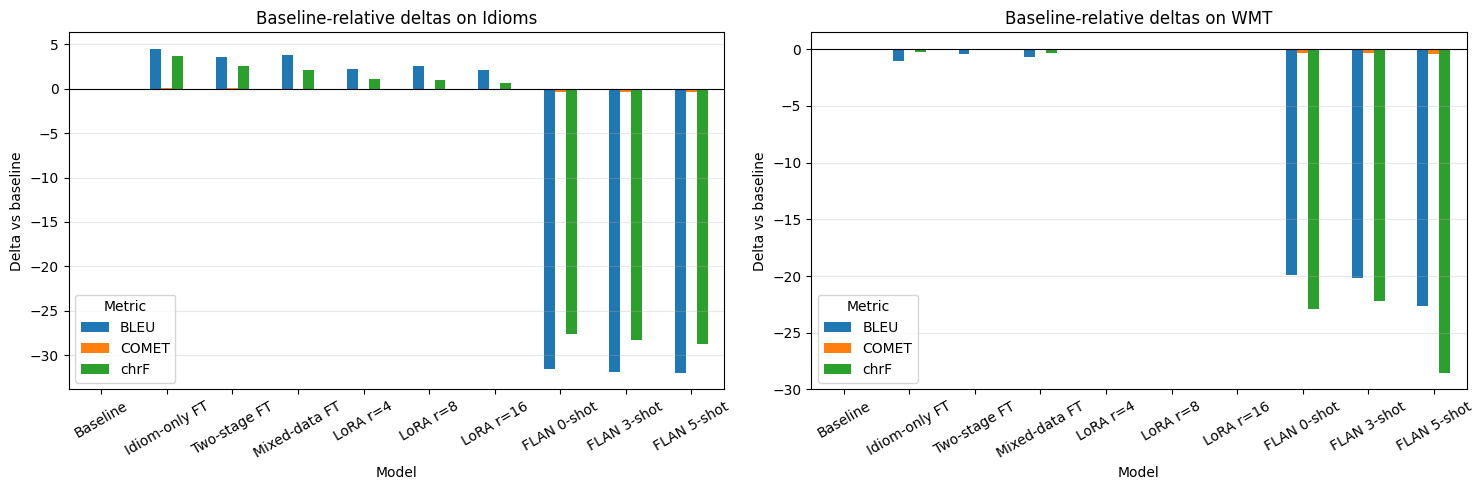

Wrote figure: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_figure_tradeoff_comet.png


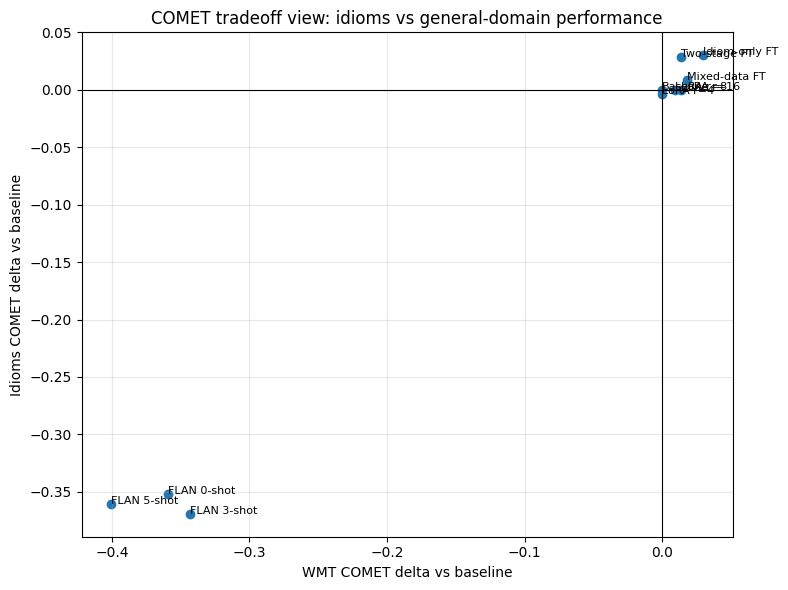

In [31]:

import matplotlib.pyplot as plt

# Figure-ready long-format deltas for barplots
paper_plot_model_deltas = paper_tradeoff_long[[
    'model', 'split',
    'delta_bleu_vs_baseline',
    'delta_chrf_vs_baseline',
    'delta_comet_vs_baseline'
]].melt(
    id_vars=['model', 'split'],
    value_vars=[
        'delta_bleu_vs_baseline',
        'delta_chrf_vs_baseline',
        'delta_comet_vs_baseline'
    ],
    var_name='metric',
    value_name='delta_vs_baseline'
)

paper_plot_model_deltas['metric'] = paper_plot_model_deltas['metric'].map({
    'delta_bleu_vs_baseline': 'BLEU',
    'delta_chrf_vs_baseline': 'chrF',
    'delta_comet_vs_baseline': 'COMET',
})
paper_plot_model_deltas['model'] = pd.Categorical(paper_plot_model_deltas['model'], categories=MODEL_ORDER, ordered=True)
paper_plot_model_deltas['split'] = pd.Categorical(paper_plot_model_deltas['split'], categories=['Idioms', 'WMT'], ordered=True)

# Figure-ready COMET tradeoff data
paper_plot_tradeoff_comet = (
    analysis_display.pivot(index='model', columns='split', values='comet_mean')
    .reset_index()
)
paper_plot_tradeoff_comet['idioms_delta_vs_baseline'] = (
    paper_plot_tradeoff_comet['Idioms']
    - paper_plot_tradeoff_comet.loc[paper_plot_tradeoff_comet['model'] == 'Baseline', 'Idioms'].iloc[0]
)
paper_plot_tradeoff_comet['wmt_delta_vs_baseline'] = (
    paper_plot_tradeoff_comet['WMT']
    - paper_plot_tradeoff_comet.loc[paper_plot_tradeoff_comet['model'] == 'Baseline', 'WMT'].iloc[0]
)
paper_plot_tradeoff_comet['model'] = pd.Categorical(paper_plot_tradeoff_comet['model'], categories=MODEL_ORDER, ordered=True)
paper_plot_tradeoff_comet = paper_plot_tradeoff_comet.sort_values('model').reset_index(drop=True)

# Figure 1: baseline-relative model deltas by metric and split
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, split_name in zip(axes, ['Idioms', 'WMT']):
    split_df = paper_plot_model_deltas[paper_plot_model_deltas['split'] == split_name].pivot(
        index='model', columns='metric', values='delta_vs_baseline'
    ).reindex(MODEL_ORDER)
    split_df.plot(kind='bar', ax=ax, rot=30)
    ax.set_title(f'Baseline-relative deltas on {split_name}')
    ax.set_xlabel('Model')
    ax.set_ylabel('Delta vs baseline')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Metric')

plt.tight_layout()
paper_figure_model_deltas_path = PAPER_EXPORT_DIR / 'paper_figure_model_deltas.png'
try:
    plt.savefig(paper_figure_model_deltas_path, dpi=200, bbox_inches='tight')
    print('Wrote figure:', paper_figure_model_deltas_path)
except Exception as e:
    print('FAILED figure export:', paper_figure_model_deltas_path)
    print(' ', e)
plt.show()

# Figure 2: COMET idioms-vs-WMT tradeoff
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    paper_plot_tradeoff_comet['wmt_delta_vs_baseline'],
    paper_plot_tradeoff_comet['idioms_delta_vs_baseline']
)

for _, row in paper_plot_tradeoff_comet.iterrows():
    ax.annotate(row['model'], (row['wmt_delta_vs_baseline'], row['idioms_delta_vs_baseline']), fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('WMT COMET delta vs baseline')
ax.set_ylabel('Idioms COMET delta vs baseline')
ax.set_title('COMET tradeoff view: idioms vs general-domain performance')
ax.grid(alpha=0.3)
plt.tight_layout()
paper_figure_tradeoff_comet_path = PAPER_EXPORT_DIR / 'paper_figure_tradeoff_comet.png'
try:
    plt.savefig(paper_figure_tradeoff_comet_path, dpi=200, bbox_inches='tight')
    print('Wrote figure:', paper_figure_tradeoff_comet_path)
except Exception as e:
    print('FAILED figure export:', paper_figure_tradeoff_comet_path)
    print(' ', e)
plt.show()


## 15. Curated qualitative examples for the paper

These exports are meant to support:
- sentence predictions in the report or deck
- qualitative examples that illustrate why metric choice changes the apparent ranking
- targeted examples for idiom-heavy and general-domain cases


In [32]:
# Curate example candidates from the highest COMET-spread examples in each split
spread_display = spread.copy()
spread_display['group'] = spread_display['group'].astype(str)
spread_display['split'] = spread_display['group'].map(SPLIT_DISPLAY_MAP).fillna(spread_display['group'])

paper_example_candidates = (
    spread_display
    .sort_values(['split', 'comet_spread'], ascending=[True, False])
    .groupby('split', group_keys=False)
    .head(6)
    [['group', 'split', 'src', 'ref', 'comet_min', 'comet_max', 'comet_spread']]
    .reset_index(drop=True)
)

example_model_subset = [
    'baseline',
    'idiom_only_v1',
    'two_stage_frozen_v1',
    'mixed_data_v1',
    'lora_r8_stage2',
    'flan_t5_small_prompt_0shot',
]

# Standardize candidate prediction columns so paper-facing exports are stable
example_scores = scores.copy()
rename_map = {}
if 'source' in example_scores.columns and 'src' not in example_scores.columns:
    rename_map['source'] = 'src'
if 'reference' in example_scores.columns and 'ref' not in example_scores.columns:
    rename_map['reference'] = 'ref'
if 'prediction' in example_scores.columns and 'pred' not in example_scores.columns:
    rename_map['prediction'] = 'pred'
if 'comet_score' in example_scores.columns and 'comet' not in example_scores.columns:
    rename_map['comet_score'] = 'comet'
example_scores = example_scores.rename(columns=rename_map)
example_scores['group'] = example_scores['group'].astype(str)

# Try to augment sentence-level BLEU/chrF if they are not already present in the COMET sentence table
if not {'bleu', 'chrf'}.issubset(example_scores.columns):
    merged_sentence = merged_metrics.copy()
    merged_rename_map = {}
    if 'source' in merged_sentence.columns and 'src' not in merged_sentence.columns:
        merged_rename_map['source'] = 'src'
    if 'reference' in merged_sentence.columns and 'ref' not in merged_sentence.columns:
        merged_rename_map['reference'] = 'ref'
    if 'prediction' in merged_sentence.columns and 'pred' not in merged_sentence.columns:
        merged_rename_map['prediction'] = 'pred'
    if 'comet_score' in merged_sentence.columns and 'comet' not in merged_sentence.columns:
        merged_rename_map['comet_score'] = 'comet'
    merged_sentence = merged_sentence.rename(columns=merged_rename_map)

    merge_keys = [c for c in ['group', 'src', 'ref', 'model'] if c in example_scores.columns and c in merged_sentence.columns]
    metric_cols = [c for c in ['bleu', 'chrf'] if c in merged_sentence.columns]

    if len(merge_keys) == 4 and metric_cols:
        metric_lookup = merged_sentence[merge_keys + metric_cols].drop_duplicates(merge_keys)
        example_scores = example_scores.merge(metric_lookup, on=merge_keys, how='left', suffixes=('', '_lookup'))
        for metric_col in metric_cols:
            lookup_col = f'{metric_col}_lookup'
            if lookup_col in example_scores.columns:
                if metric_col in example_scores.columns:
                    example_scores[metric_col] = example_scores[metric_col].fillna(example_scores[lookup_col])
                    example_scores = example_scores.drop(columns=[lookup_col])
                else:
                    example_scores = example_scores.rename(columns={lookup_col: metric_col})

paper_example_predictions = (
    example_scores
    .merge(
        paper_example_candidates[['group', 'split', 'src', 'ref']],
        on=['group', 'src', 'ref'],
        how='inner'
    )
    .loc[lambda d: d['model'].isin(example_model_subset)]
    .copy()
)

paper_example_predictions['split'] = (
    paper_example_predictions['group']
    .map(SPLIT_DISPLAY_MAP)
    .fillna(paper_example_predictions['split'])
)
paper_example_predictions['model_display'] = (
    paper_example_predictions['model']
    .map(MODEL_DISPLAY_MAP)
    .fillna(paper_example_predictions['model'])
)
paper_example_predictions['model_short'] = (
    paper_example_predictions['model_display']
    .str.replace(' Fine-tune', '', regex=False)
    .str.replace(' Full Fine-tune', '', regex=False)
    .str.replace(' Stage 2', '', regex=False)
    .str.replace('Prompting ', '', regex=False)
    .str.replace(' 0-shot', ' 0-shot', regex=False)
)

prediction_cols = ['group', 'split', 'src', 'ref', 'model', 'model_display', 'model_short']
for candidate_col in ['pred', 'prediction', 'bleu', 'chrf', 'comet', 'comet_score']:
    if candidate_col in paper_example_predictions.columns and candidate_col not in prediction_cols:
        prediction_cols.append(candidate_col)

paper_example_predictions = (
    paper_example_predictions[prediction_cols]
    .sort_values(['split', 'src', 'model_display'])
    .reset_index(drop=True)
)

display(paper_example_candidates)
display(paper_example_predictions.head(30))


,group,split,src,ref,comet_min,comet_max,comet_spread
0,idioms_test,Idioms,But before she could launch her charm offensiv...,Doch bevor sie ihre Charmeoffensive starten ko...,0.169645,0.945956,0.776311
1,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",0.282064,0.917172,0.635108
2,idioms_test,Idioms,"For the young Canadian servicemen, the order t...",Die jungen kanadischen Soldaten erwarteten täg...,0.180694,0.812785,0.632091
3,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",0.290774,0.876986,0.586211
4,idioms_test,Idioms,We're cut from the same cloth as any American ...,Wir sind aus dem gleichen Holz geschnitzt wie ...,0.336061,0.907208,0.571148
5,idioms_test,Idioms,"It would certainly be fun in an active family,...",Es wäre sicher lustig in einer aktiven Familie...,0.367450,0.909396,0.541946
6,wmt_test,WMT,"However, if no new orders are announced in the...",Falls allerdings in den kommenden Monaten kein...,0.295748,0.918535,0.622787
7,wmt_test,WMT,"Meanwhile, U.S. lawmakers will head to Europe ...",Unterdessen werden US-amerikanische Gesetzgebe...,0.267089,0.889408,0.622318
8,wmt_test,WMT,All three face a maximum penalty of life impri...,Allen dreien droht als Höchststrafe lebenslang...,0.271974,0.889371,0.617396
9,wmt_test,WMT,"""Decisions will then be made elsewhere,"" said ...","""Dann werden Entscheidungen an anderer Stelle ...",0.333581,0.943284,0.609703


,group,split,src,ref,model,model_display,model_short,pred,comet
0,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",baseline,Baseline,Baseline,Unabhängig von ihrer Ursache sind Ungleichheit...,0.842750
1,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",flan_t5_small_prompt_0shot,FLAN 0-shot,FLAN 0-shot,"""Eigengleichheiten sind eine starken Kräfte fü...",0.290774
2,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",idiom_only_v1,Idiom-only FT,Idiom-only FT,"""Ungleichbehandlungen sind unabhängig von ihre...",0.876986
3,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r8_stage2,LoRA r=8,LoRA r=8,"""Ungleich, was ihre Ursache betrifft, sind Ung...",0.827501
4,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",mixed_data_v1,Mixed-data FT,Mixed-data FT,Unabhängig von ihrer Ursache sind Ungleichheit...,0.836074
5,idioms_test,Idioms,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",two_stage_frozen_v1,Two-stage FT,Two-stage FT,Unabhängig von ihrer Ursache sind Ungleichheit...,0.843890
6,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",baseline,Baseline,Baseline,"Gib zu, dass ich dein rechtmäßiger König bin!",0.799448
7,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",flan_t5_small_prompt_0shot,FLAN 0-shot,FLAN 0-shot,"Benden die Knee, peasant! Admit, dass ich Ihre...",0.347663
8,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",idiom_only_v1,Idiom-only FT,Idiom-only FT,"Kniebeugen, Bauer! Gib zu, dass ich dein recht...",0.917172
9,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",lora_r8_stage2,LoRA r=8,LoRA r=8,"Gib zu, dass ich dein rechtmäßiger König bin!",0.799448


## 16. Paper-facing interpretation summary

This section keeps the automatic-analysis notebook aligned with the main storyline for the paper:
- Under BLEU and chrF, more balanced adaptation strategies appeared stronger.
- Under COMET, idiom-only fine-tuning rises substantially and performs best across both splits.
- The expected tradeoff between idiom specialization and general-domain performance weakens substantially under semantic evaluation.
- This metric shift motivates the paper’s main claim, while notebook 12 supplies the human-evaluation nuance layer.


In [33]:

paper_interpretation = [
    "BLEU/chrF suggest more balanced strategies, especially LoRA variants, remain highly competitive.",
    "COMET changes the ranking landscape: idiom-only fine-tuning becomes the top model on both idioms and WMT.",
    "Under COMET, the expected catastrophic-forgetting story weakens substantially relative to the overlap metrics.",
    "Notebook 12 should be read as the human-evaluation validation/nuance layer rather than as a replacement for these automatic results.",
]

for point in paper_interpretation:
    print("-", point)


- BLEU/chrF suggest more balanced strategies, especially LoRA variants, remain highly competitive.
- COMET changes the ranking landscape: idiom-only fine-tuning becomes the top model on both idioms and WMT.
- Under COMET, the expected catastrophic-forgetting story weakens substantially relative to the overlap metrics.
- Notebook 12 should be read as the human-evaluation validation/nuance layer rather than as a replacement for these automatic results.


## 17. Export paper-ready automatic-evaluation artifacts

All exported files are written to `results/automatic_eval_outputs/` inside the project directory.


In [34]:

paper_exports = {
    'paper_table_automatic_by_split.csv': paper_table_automatic_by_split,
    'paper_table_metric_rankings.csv': paper_table_metric_rankings,
    'paper_table_tradeoff_summary.csv': paper_table_tradeoff_summary,
    'paper_plot_model_deltas.csv': paper_plot_model_deltas,
    'paper_plot_tradeoff_comet.csv': paper_plot_tradeoff_comet,
    'paper_example_candidates.csv': paper_example_candidates,
    'paper_example_predictions.csv': paper_example_predictions,
}

failed_exports = []

for filename, df in paper_exports.items():
    out_path = PAPER_EXPORT_DIR / filename
    try:
        df.to_csv(out_path, index=False)
        print("Wrote:", out_path)
    except Exception as e:
        failed_exports.append((filename, str(e)))
        print("FAILED:", out_path)
        print("  ", e)

print("\nPaper export complete.")
if failed_exports:
    print("\nFailed exports:")
    for filename, err in failed_exports:
        print(f"- {filename}: {err}")
else:
    print("All paper-facing CSV exports succeeded.")

print("\nCurrent files in paper export directory:")
display(pd.Series(sorted([p.name for p in PAPER_EXPORT_DIR.glob('*')]), name='paper_export_file'))


Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_table_automatic_by_split.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_table_metric_rankings.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_table_tradeoff_summary.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_plot_model_deltas.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_plot_tradeoff_comet.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_example_candidates.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_eval_outputs/paper_example_predictions.csv

Paper export complete.
All paper-facing CSV exports succeeded.

Current files in paper export directory:


,paper_export_file
0,paper_example_candidates.csv
1,paper_example_predictions.csv
2,paper_figure_model_deltas.png
3,paper_figure_tradeoff_comet.png
4,paper_plot_model_deltas.csv
5,paper_plot_tradeoff_comet.csv
6,paper_table_automatic_by_split.csv
7,paper_table_metric_rankings.csv
8,paper_table_tradeoff_summary.csv
